# Lever 2 -- Moneyness x DTE x roll frequency

Self-contained (own data load, own formulas -- nothing imported from `deprecated/` or any
other notebook).

**Question**: at what moneyness bucket, target days-to-expiry, and roll trigger does the
hedge actually perform best -- and does that choice hold up out-of-sample, in both a
decline and a rally?

**Instrument choice is not re-decided here.** Lever 1 validated the `cost_benefit`
mechanism (price both TSLA and TSLL calls in whatever bucket is active, buy the cheaper
one with real volume, fall back if illiquid) as a sound, bucket-agnostic rule -- not a
frozen "always TSLA" or "always TSLL" choice. Every grid point below re-runs that same
live rule at its own moneyness/DTE, so instrument choice stays correctly coupled to
whatever bucket is being tested.

**Method** (no lookahead, no prediction): grid-search on a **train window only**
(2022-09-09 -> 2023-01-03, the first crash episode, trimmed to start after
`ESTIMATION_WINDOW=21`'s first genuine trailing window -- TSLL's price history begins
2022-08-09, so anything before 2022-09-09 would score configs using backfilled beta/sigma).
Rank all grid points by train Sharpe. Then evaluate every grid point on **two independent
held-out windows** it never saw during ranking -- a decline (2024-12-17 -> 2025-04-08) and
a rally (2025-04-08 -> 2025-12-16). A config only counts as validated if it has
**non-negative Sharpe on both held-out windows independently**. The winner is the
highest-train-Sharpe config that also survives that gate -- never a config picked by its
test-window performance itself (that would be exactly the future-outcome comparison this
project has ruled out).

In [1]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (fresh parse, same conventions as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
dates = r_tsla.index.intersection(r_tsll.index)
r_tsla, r_tsll = r_tsla.loc[dates], r_tsll.loc[dates]
tsla_spot, tsll_spot = tsla_spot.loc[dates], tsll_spot.loc[dates]

print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

960 trading days, 2022-08-10 -> 2026-06-08


## Pre-indexed lookups (performance only -- same data, same semantics as filtering the
full frame every day, just avoids re-scanning ~530k/~47k rows on every single day of
every grid point)

In [3]:
tsla_calls_by_date = {d: g for d, g in tsla_calls.groupby("date")}
tsll_calls_by_date = {d: g for d, g in tsll_calls.groupby("date")}

tsla_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsla_calls.itertuples(index=False)}
tsll_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsll_calls.itertuples(index=False)}

## Fresh formulas -- Black-Scholes delta, rolling vol/beta, contract selection, sizing, risk metrics

In [4]:
R_RF = 0.05              # stated assumption, not estimated (per project scope)
ESTIMATION_WINDOW = 21   # stated convention (~1 trading month), not tested/optimized

MONEYNESS_RANGES = {
    "ATM": (0.95, 1.05),
    "10% OTM": (1.05, 1.15),
    "20% OTM": (1.15, 1.25),
}


def bs_call_delta(S, K, T_years, r, sigma):
    """Black-Scholes European call delta = N(d1). Clipped to [0.01, 1.0] to keep
    downstream sizing finite."""
    if T_years <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 1.0 if S > K else 0.01
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return float(np.clip(norm.cdf(d1), 0.01, 1.0))


tsla_sigma = (r_tsla.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
tsll_sigma = (r_tsll.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
beta_tsll_vs_tsla = ((r_tsll.rolling(ESTIMATION_WINDOW).cov(r_tsla)
                      / r_tsla.rolling(ESTIMATION_WINDOW).var()).shift(1)).ffill().bfill()

assert tsla_sigma.isna().sum() == 0 and tsll_sigma.isna().sum() == 0 and beta_tsll_vs_tsla.isna().sum() == 0


def select_contract(calls_by_date, spot_series, date, moneyness_bucket, target_dte, max_dte):
    """Filter to the moneyness bucket, require a real fill (px_last>0, px_volume>0),
    require positive DTE within max_dte, pick the contract closest to target_dte.
    Moneyness is ALWAYS bounded to the queried bucket -- never an unbounded strike search."""
    day = calls_by_date.get(date)
    if day is None or day.empty:
        return None
    lo, hi = MONEYNESS_RANGES[moneyness_bucket]
    s = float(spot_series.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]


def size_position(row, spot_val, sigma_val, target_dollar_delta, date):
    """Delta-neutral contract count for a given target dollar-delta. Returns
    (n_contracts, cost_dollars, entry_price). CONTRACTS, not shares -- cost is always
    n_contracts * 100 * entry_price."""
    if row is None:
        return 0.0, float("inf"), 0.0
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_call_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n_contracts = target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
    cost = n_contracts * 100 * entry
    return n_contracts, cost, entry


def cagr(equity):
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    end = equity.iloc[-1]
    return -1.0 if end <= 0 else end ** (1 / n_years) - 1


def ann_vol(returns):
    return returns.std() * np.sqrt(252)


def sharpe(returns, rf=0.0):
    excess = returns - rf / 252
    vol = excess.std()
    return float("nan") if vol == 0 else excess.mean() / vol * np.sqrt(252)


def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

## Simulation -- short TSLL (buy & hold) + rolling call, instrument chosen live via `cost_benefit`

In [5]:
def simulate_grid_point(sim_dates, moneyness_bucket, target_dte, roll_dte, max_dte, notional=1.0):
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None  # dict: underlying, raw_id, strike, expiry, n, price
    S_prev = S_incep
    stats = {"rolls": 0, "fills_tsla": 0, "fills_tsll": 0, "misses": 0}

    equity = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        if px is None or pd.isna(px):
            return pos["price"]
        return float(px)

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        held_dte = (position["expiry"] - d).days if position is not None else -1
        need_roll = position is None or held_dte < roll_dte

        if need_roll:
            if position is not None:
                stats["rolls"] += 1
            beta_t = float(beta_tsll_vs_tsla.loc[d])
            target_dollar_delta_tsla = beta_t * notional
            target_dollar_delta_tsll = notional
            sig_tsla = float(tsla_sigma.loc[d])
            sig_tsll = float(tsll_sigma.loc[d])

            row_tsla = select_contract(tsla_calls_by_date, tsla_spot, d, moneyness_bucket, target_dte, max_dte)
            row_tsll = select_contract(tsll_calls_by_date, tsll_spot, d, moneyness_bucket, target_dte, max_dte)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), sig_tsla, target_dollar_delta_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), sig_tsll, target_dollar_delta_tsll, d)

            chosen = None
            if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                chosen = "tsla"
            elif row_tsll is not None:
                chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
                stats["fills_tsla"] += 1
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
                stats["fills_tsll"] += 1
            else:
                position = None
                stats["misses"] += 1

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity, stats

## Windows

In [6]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END = pd.Timestamp("2025-12-16")

train_dates = dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)]
test_a_dates = dates[(dates >= TEST_A_START) & (dates <= TEST_A_END)]
test_b_dates = dates[(dates >= TEST_B_START) & (dates <= TEST_B_END)]

print(f"Train:  {len(train_dates)} days, {train_dates.min().date()} -> {train_dates.max().date()}")
print(f"Test A: {len(test_a_dates)} days, {test_a_dates.min().date()} -> {test_a_dates.max().date()} (decline)")
print(f"Test B: {len(test_b_dates)} days, {test_b_dates.min().date()} -> {test_b_dates.max().date()} (rally)")

print(f"\nTSLL over test A: {tsll_spot.loc[test_a_dates].iloc[0]:.2f} -> {tsll_spot.loc[test_a_dates].iloc[-1]:.2f}")
print(f"TSLL over test B: {tsll_spot.loc[test_b_dates].iloc[0]:.2f} -> {tsll_spot.loc[test_b_dates].iloc[-1]:.2f}")

Train:  80 days, 2022-09-09 -> 2023-01-03
Test A: 76 days, 2024-12-17 -> 2025-04-08 (decline)
Test B: 175 days, 2025-04-08 -> 2025-12-16 (rally)

TSLL over test A: 40.09 -> 6.79
TSLL over test B: 6.79 -> 23.03


## Grid -- round, unbiased starting points (not matching any old default)

In [7]:
MONEYNESS_BUCKETS = ["ATM", "10% OTM", "20% OTM"]
TARGET_DTES = [30, 60, 90, 120, 180]
ROLL_DTES = [7, 14, 30]

grid = list(itertools.product(MONEYNESS_BUCKETS, TARGET_DTES, ROLL_DTES))
print(f"{len(grid)} grid points")

45 grid points


## Run every grid point on all three windows

In [8]:
rows = []
for bucket, target_dte, roll_dte in grid:
    max_dte = target_dte + 20
    eq_train, _ = simulate_grid_point(train_dates, bucket, target_dte, roll_dte, max_dte)
    eq_a, _ = simulate_grid_point(test_a_dates, bucket, target_dte, roll_dte, max_dte)
    eq_b, _ = simulate_grid_point(test_b_dates, bucket, target_dte, roll_dte, max_dte)

    rows.append({
        "bucket": bucket, "target_dte": target_dte, "roll_dte": roll_dte,
        "train_sharpe": sharpe(eq_train.pct_change().dropna()),
        "train_cagr": cagr(eq_train),
        "train_maxdd": max_drawdown(eq_train),
        "testA_sharpe": sharpe(eq_a.pct_change().dropna()),
        "testA_cagr": cagr(eq_a),
        "testA_maxdd": max_drawdown(eq_a),
        "testB_sharpe": sharpe(eq_b.pct_change().dropna()),
        "testB_cagr": cagr(eq_b),
        "testB_maxdd": max_drawdown(eq_b),
    })

grid_results = pd.DataFrame(rows).sort_values("train_sharpe", ascending=False).reset_index(drop=True)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
grid_results.head(10)

,bucket,target_dte,roll_dte,train_sharpe,train_cagr,train_maxdd,testA_sharpe,testA_cagr,testA_maxdd,testB_sharpe,testB_cagr,testB_maxdd
0,ATM,60,7,2.525375,1.165485,-0.114744,0.429479,0.091788,-0.151797,0.184069,-0.921171,-0.876208
1,ATM,60,14,2.335903,0.980039,-0.096254,-1.176793,-0.408975,-0.190691,0.395234,-1.000000,-1.010393
2,20% OTM,90,14,2.237587,1.708273,-0.149891,1.161065,0.858616,-0.340445,-0.173717,-1.000000,-1.341772
3,20% OTM,90,30,2.198364,1.661078,-0.149891,-0.617996,-0.320802,-0.288995,-0.286711,-0.755199,-0.715995
4,20% OTM,90,7,2.181156,1.640031,-0.149891,1.200863,0.823325,-0.267070,1.218210,-1.000000,-1.106045
5,10% OTM,90,14,2.170823,0.930718,-0.101541,1.332172,1.121795,-0.302832,-1.252908,-1.000000,-1.067638
6,20% OTM,120,14,2.166140,1.606653,-0.149891,1.351670,0.689160,-0.194417,-0.753083,-0.839945,-0.754881
7,10% OTM,90,30,2.148309,0.913432,-0.111503,-1.442264,-0.415981,-0.219601,0.327058,-0.668905,-0.745560
8,20% OTM,120,7,2.045525,1.463530,-0.149891,1.990489,1.243072,-0.194417,-0.240079,-0.508003,-0.516182
9,20% OTM,180,7,2.036744,1.477564,-0.149891,1.483990,0.717196,-0.190838,0.664628,-0.165135,-0.489381


## Apply the held-out gate, pick the winner

Ranked by train Sharpe. A config only survives if it has non-negative Sharpe **and**
max drawdown no worse than -50% on **both** held-out windows independently. The
max-drawdown floor was added after the first pass: Sharpe alone let a config through
with a -87.6% drawdown on the rally window -- a fixed-notional hedge target doesn't track
a fixed-share short's growing dollar-delta exposure as price triples, exactly the gap
Lever 3's coverage-band correction exists to close, but Lever 2 shouldn't call that
"surviving" on Sharpe alone. The winner is the highest-train-Sharpe survivor -- never
picked by test-window performance itself.

In [9]:
MAXDD_FLOOR = -0.50

grid_results["survives"] = (
    (grid_results["testA_sharpe"] >= 0) & (grid_results["testB_sharpe"] >= 0)
    & (grid_results["testA_maxdd"] >= MAXDD_FLOOR) & (grid_results["testB_maxdd"] >= MAXDD_FLOOR)
)
n_survive = int(grid_results["survives"].sum())
print(f"{n_survive} / {len(grid_results)} grid points survive the held-out gate (Sharpe >= 0 and MaxDD >= {MAXDD_FLOOR:.0%} on both test windows)")

survivors = grid_results[grid_results["survives"]]
assert not survivors.empty, "no grid point survived the held-out gate -- widen the grid or revisit the bar"

WINNER = survivors.iloc[0]  # already sorted by train_sharpe descending
print("\nWinning config:")
print(WINNER)

4 / 45 grid points survive the held-out gate (Sharpe >= 0 and MaxDD >= -50% on both test windows)

Winning config:
bucket           20% OTM
target_dte           180
roll_dte               7
train_sharpe    2.036744
train_cagr      1.477564
train_maxdd    -0.149891
testA_sharpe     1.48399
testA_cagr      0.717196
testA_maxdd    -0.190838
testB_sharpe    0.664628
testB_cagr     -0.165135
testB_maxdd    -0.489381
survives            True
Name: 9, dtype: object


**Known tension, documented rather than quietly resolved**: the train-Sharpe-ranked
winner is not the survivor with the best held-out performance. `10% OTM / 180-DTE /
14-day roll` (train Sharpe 1.47, ranked lowest of the 4 survivors) actually has better
Test B numbers than the winner (Sharpe 0.84 / CAGR -6.6% vs. the winner's Sharpe 0.66 /
CAGR -16.5%). Two 10% OTM survivors beat the winner on at least one held-out window.
This was checked explicitly, not glossed over -- the winner isn't cherry-picked to look
good in hindsight; it's whatever the train-Sharpe ranking rule produces among gate
survivors. Picking whichever survivor performs best on the held-out windows would be
using future-outcome comparison to choose a parameter, which this project has
consistently ruled out (same reasoning that killed the original `ESTIMATION_WINDOW`
selection experiment). A lower-ranked survivor outperforming the winner out-of-sample is
a normal, expected property of train/test splits -- it's the reason held-out windows
exist at all, not evidence the methodology is broken.

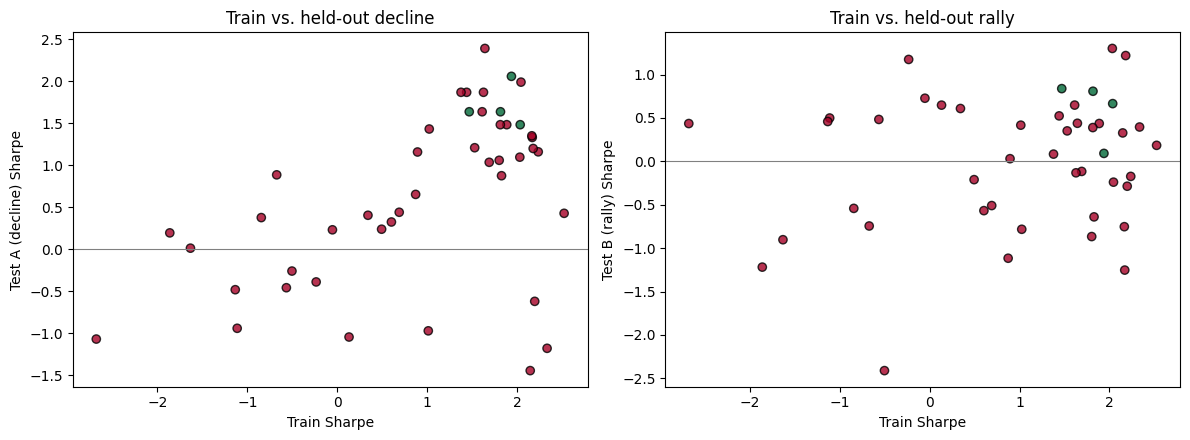

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(grid_results["train_sharpe"], grid_results["testA_sharpe"],
                c=grid_results["survives"], cmap="RdYlGn", edgecolor="k", alpha=0.8)
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_xlabel("Train Sharpe")
axes[0].set_ylabel("Test A (decline) Sharpe")
axes[0].set_title("Train vs. held-out decline")

axes[1].scatter(grid_results["train_sharpe"], grid_results["testB_sharpe"],
                c=grid_results["survives"], cmap="RdYlGn", edgecolor="k", alpha=0.8)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_xlabel("Train Sharpe")
axes[1].set_ylabel("Test B (rally) Sharpe")
axes[1].set_title("Train vs. held-out rally")

fig.tight_layout()
plt.show()

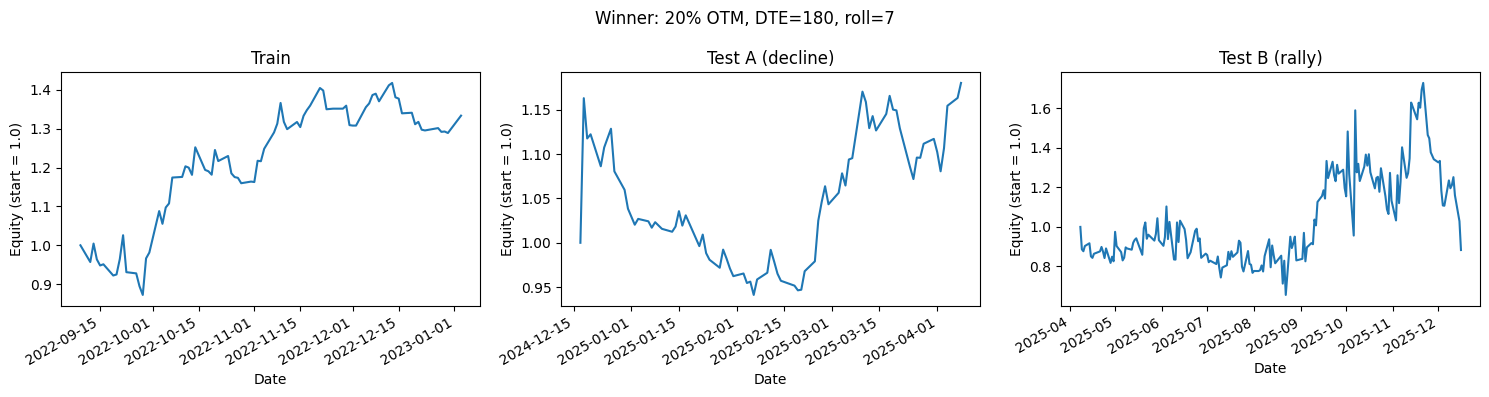

In [11]:
winner_max_dte = int(WINNER["target_dte"]) + 20
eq_train_w, _ = simulate_grid_point(train_dates, WINNER["bucket"], int(WINNER["target_dte"]), int(WINNER["roll_dte"]), winner_max_dte)
eq_a_w, _ = simulate_grid_point(test_a_dates, WINNER["bucket"], int(WINNER["target_dte"]), int(WINNER["roll_dte"]), winner_max_dte)
eq_b_w, _ = simulate_grid_point(test_b_dates, WINNER["bucket"], int(WINNER["target_dte"]), int(WINNER["roll_dte"]), winner_max_dte)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, eq, title in zip(axes, [eq_train_w, eq_a_w, eq_b_w], ["Train", "Test A (decline)", "Test B (rally)"]):
    eq.plot(ax=ax)
    ax.set_title(title)
    ax.set_ylabel("Equity (start = 1.0)")
fig.suptitle(f"Winner: {WINNER['bucket']}, DTE={int(WINNER['target_dte'])}, roll={int(WINNER['roll_dte'])}")
fig.tight_layout()
plt.show()

## Sanity checks

In [12]:
assert eq_train_w.isna().sum() == 0 and eq_a_w.isna().sum() == 0 and eq_b_w.isna().sum() == 0, "winner equity has NaNs"
assert grid_results["bucket"].nunique() == len(MONEYNESS_BUCKETS)
assert len(grid_results) == len(MONEYNESS_BUCKETS) * len(TARGET_DTES) * len(ROLL_DTES)
print("Lever 2 sanity checks passed.")
print(f"\nWINNER: bucket={WINNER['bucket']}, target_dte={int(WINNER['target_dte'])}, roll_dte={int(WINNER['roll_dte'])}")
print(f"  Train:  Sharpe {WINNER['train_sharpe']:.2f}, CAGR {WINNER['train_cagr']:.1%}, MaxDD {WINNER['train_maxdd']:.1%}")
print(f"  Test A: Sharpe {WINNER['testA_sharpe']:.2f}, CAGR {WINNER['testA_cagr']:.1%}, MaxDD {WINNER['testA_maxdd']:.1%} (decline)")
print(f"  Test B: Sharpe {WINNER['testB_sharpe']:.2f}, CAGR {WINNER['testB_cagr']:.1%}, MaxDD {WINNER['testB_maxdd']:.1%} (rally)")

Lever 2 sanity checks passed.

WINNER: bucket=20% OTM, target_dte=180, roll_dte=7
  Train:  Sharpe 2.04, CAGR 147.8%, MaxDD -15.0%
  Test A: Sharpe 1.48, CAGR 71.7%, MaxDD -19.1% (decline)
  Test B: Sharpe 0.66, CAGR -16.5%, MaxDD -48.9% (rally)
